In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance 
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sklearn.metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score

def last_noNaN_index(serie):
    return((~np.isnan(serie.flatten())).cumsum(0).argmax(0))

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

def my_scaler(data, feature_range = (0,1)): #list of series
    global_min = np.min([np.min(np.log(serie)) for serie in data])
    global_max = np.max([np.max(np.log(serie)) for serie in data])
    data_scaled = []
    for serie in data:
        serie = np.log(serie)
        serie = (serie - global_min) / (global_max - global_min)
        serie = serie * (feature_range[1] - feature_range[0]) + feature_range[0]
        data_scaled.append(serie)
    return(data_scaled)

def encode_sequence_1dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def encode_sequence_2dim(vrae_model, sequence):
    vrae_model.eval()
    vrae_model.batch_size = 1
    input_seq = torch.from_numpy(sequence).float().unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_model.transform(input_seq)
    return latent[0,:]

def forward_sequence_1dim(vrae_model, sequence):
    if sequence.shape[0]>vrae_model.sequence_length:
        print(f'Sequence not {vrae_model.sequence_length}')
        return(-1)
    vrae_model.eval()
    fake_batch_200 = np.tile(sequence, (200, 1)).T
    fake_batch_200 = torch.from_numpy(fake_batch_200).float().unsqueeze(2).cuda()
    reconstruction = vrae_model.forward(fake_batch_200)
    return reconstruction[0][:,0,:].cpu().detach().numpy()

# df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
# df_tracks= df.pivot(values=[
#     'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
#     'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
#     'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
#     'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
#     'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
#     'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
#     index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
#     columns='Time')

X_train shape	 (63266, 96, 2) 	 X_test shape	 (7030, 96, 2)


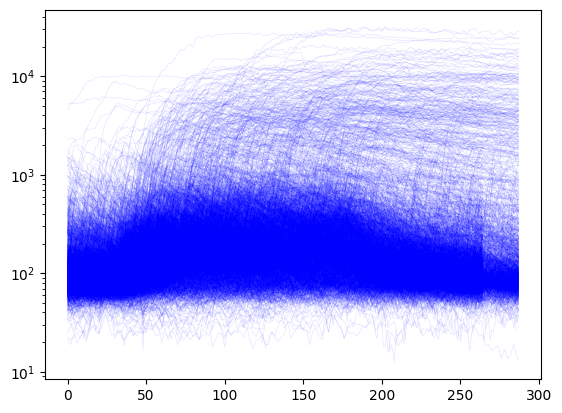

In [2]:
### Creating dataset and splitting it into train and test sets then data augmentation
# liste_x=[]
# liste_y=[]

# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']

# for exp_name in dataset_name_list:

#     medium,treatment,replicate = exp_name.split('_')

#     frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
#     size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
#     cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
#     sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
#     mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

#     DeathSubtype = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])

#     for i in range(size_array.shape[0]):
#         ##fill nans missing timepoints with the mean of the previous and next timepoints
#         size_serie =  size_array[i]
#         for j in range(1,len(size_serie)-1):
#             if np.isnan(size_serie[j]):
#                 size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

#         sos_serie = sos_array[i]
#         for j in range(1,len(sos_serie)-1):
#             if np.isnan(sos_serie[j]):
#                 sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
#         mcherry_serie = mcherry_array[i]
#         for j in range(1,len(mcherry_serie)-1):
#             if np.isnan(mcherry_serie[j]):
#                 mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

#         cyclefate_serie = cyclefate_array[i]
#         for j in range(len(cyclefate_serie)-1):
#             if cyclefate_serie[j] == 'nan':
#                 cyclefate_serie[j] = cyclefate_serie[j+1]

#         t_death = len(cyclefate_serie)
#         if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
#             t_death = np.where(cyclefate_serie != 'alive')[0][0]

#         # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
#         first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

#         if first_NaN>96:
#             last_usable_timepoint = min(first_NaN,288)
#             liste_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
#             liste_y.append((medium,treatment,replicate,t_death,DeathSubtype[i]))
# #scan for NANs in all liste_x
# for x in liste_x:
#     for serie in x:
#         if np.sum(np.isnan(serie))>0:
#             print('NAN found')

# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_x_SOS_training.npy',np.array(liste_x,dtype=object))
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_y_SOS_training.npy',np.array(liste_y,dtype=object))

liste_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_x_SOS_training.npy',allow_pickle=True)
liste_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\liste_y_SOS_training.npy',allow_pickle=True)

liste_x_scaled_SOS = my_scaler([x[1] for x in liste_x], feature_range=(-1,1)) #using only the SOS signal
liste_x_scaled_size = my_scaler([x[0] for x in liste_x], feature_range=(-1,1)) #using only the Size signal
combined_scaled = []
for i in range(len(liste_x_scaled_SOS)):
    combined_scaled.append(np.vstack((liste_x_scaled_size[i], liste_x_scaled_SOS[i])).T)

liste_x_train = []
liste_y_train = []
for i in range(len(combined_scaled)):
    usable_data = combined_scaled[i]
    for j in range(0, len(usable_data) - 96 + 1, 6):
        liste_x_train.append(usable_data[j:j+96,:])
        liste_y_train.append(liste_y[i])

# liste_x_train = [x[:,0,np.newaxis] for x in liste_x_train] #ensure all sequences are 96 timepoints long
X_train, X_test, y_train, y_test = train_test_split(np.array(liste_x_train)[:,:], np.array(liste_y_train), test_size=0.1, random_state=42, shuffle=False)

# save those 4 arrays
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\test folder\X_train_SOS_size.npy', X_train)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\test folder\X_test_SOS_size.npy', X_test)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\test folder\y_train_SOS_size.npy', y_train)
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\test folder\y_test_SOS_size.npy', y_test)



train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

for s  in  [x[1] for x in liste_x]:
    plt.plot(s,alpha=0.1,color='blue',linewidth=0.5)
plt.yscale('log')

print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

torch.Size([96, 100, 2])
95
(96, 2)


Text(0.5, 0, 'Timepoints')

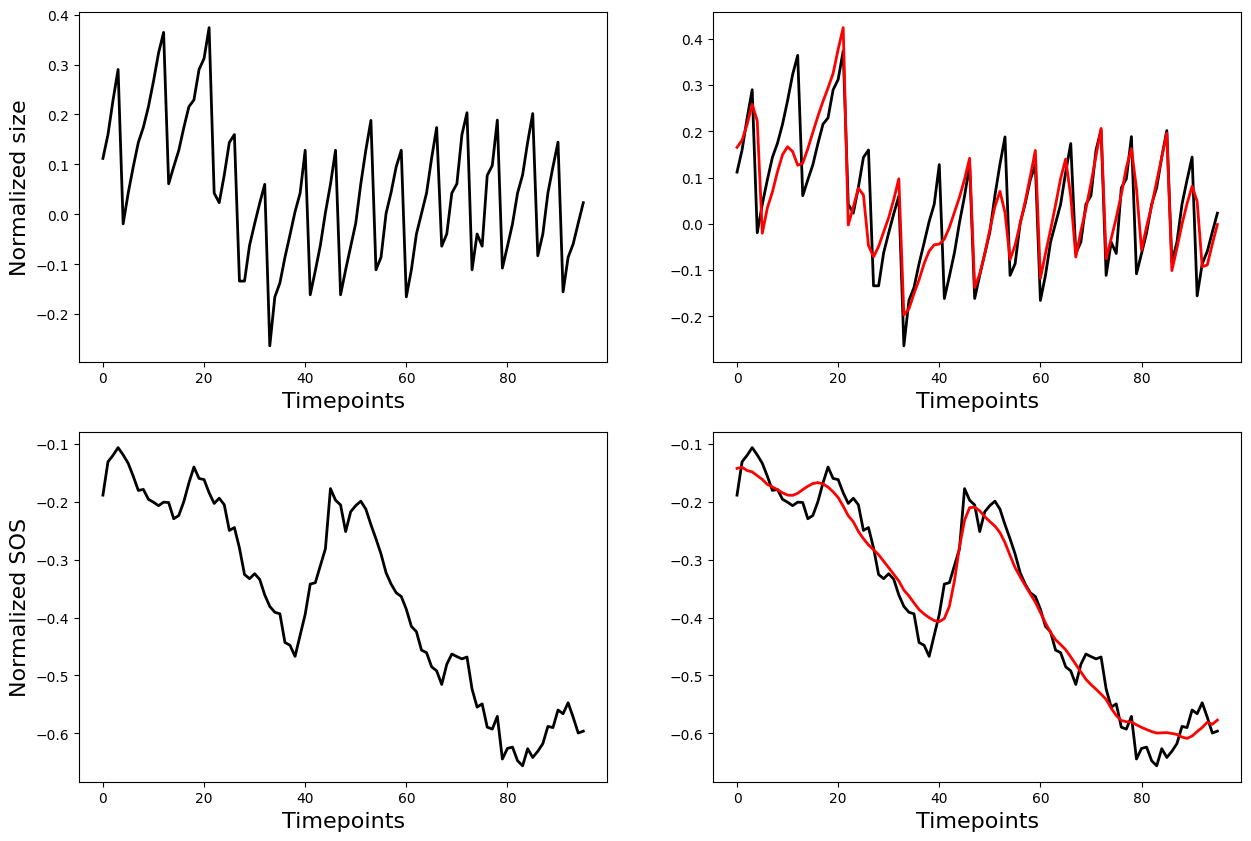

In [5]:
## load model 26 2
sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]
latent_length = 26
best_replicate = 2

dload = './model_dir_mm' #download directory
hidden_size = 90
hidden_layer_depth = 2
batch_size = 100
learning_rate = 0.0005 # 0.0005
n_epochs = 200
dropout_rate = 0.2
optimizer = 'Adam' # options: ADAM, SGD
cuda = True # options: True, False
print_every=1000
clip = True # options: True, False
max_grad_norm=5
loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
block = 'LSTM' # options: LSTM, GRU

vrae_trained = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_SOS_size_fat\model_best_{best_replicate}_{latent_length}.pth')


vrae_trained.eval()
p=3
testseq2 = test_dataset[batch_size*p:batch_size*(p+1)][0].float().permute(1, 0, 2).cuda()
print(testseq2.shape)

outp = vrae_trained.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
# k=174
input_seq = testseq2[:,k,:].cpu().detach().numpy()
output_seq = outp[0][:,k,:].cpu().detach().numpy()

fig,ax =  plt.subplots(2,2,figsize=(15,10))
print(input_seq.shape)

ax[0,0].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(input_seq[:,0], color ='black',linewidth = 2, label='input')
ax[0,1].plot(output_seq[:,0], color='red',linewidth = 2, label='reconstruction')
ax[0,0].set_xlabel('Timepoints', fontsize=16)
ax[0,0].set_ylabel('Normalized size', fontsize=16)
ax[0,1].set_xlabel('Timepoints', fontsize=16)

ax[1,0].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(input_seq[:,1], color ='black',linewidth = 2, label='input')
ax[1,1].plot(output_seq[:,1], color='red',linewidth = 2, label='reconstruction')
ax[1,0].set_xlabel('Timepoints', fontsize=16)
ax[1,0].set_ylabel('Normalized SOS', fontsize=16)
ax[1,1].set_xlabel('Timepoints', fontsize=16)

In [6]:
#### import literally everything

df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
df_tracks= df.pivot(values=[
    'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
    'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
    'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
    'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
    'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
    'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
    index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
    columns='Time')

# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1'] training set
dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
 'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']


all_data_x=[]
all_data_y=[]

for exp_name in dataset_name_list:

    medium,treatment,replicate = exp_name.split('_')

    frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
    size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
    cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
    sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
    mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])
    elongation_array = np.array([list(frame['GrowthRateFeretMax'].T[k]) for k in frame['GrowthRateFeretMax'].T.keys()])

    DeathSubtypes = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])
    Fates = np.array([i for i in frame.reset_index('fate')['fate']])

    for i in range(size_array.shape[0]):
        ##fill nans missing timepoints with the mean of the previous and next timepoints
        size_serie =  size_array[i]
        for j in range(1,len(size_serie)-1):
            if np.isnan(size_serie[j]):
                size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

        sos_serie = sos_array[i]
        for j in range(1,len(sos_serie)-1):
            if np.isnan(sos_serie[j]):
                sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
        mcherry_serie = mcherry_array[i]
        for j in range(1,len(mcherry_serie)-1):
            if np.isnan(mcherry_serie[j]):
                mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

        cyclefate_serie = cyclefate_array[i]
        for j in range(len(cyclefate_serie)-1):
            if cyclefate_serie[j] == 'nan':
                cyclefate_serie[j] = cyclefate_serie[j+1]

        t_death = len(cyclefate_serie)
        if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
            t_death = np.where(cyclefate_serie != 'alive')[0][0]

        elongation_serie = elongation_array[i]
        for j in range(1,len(elongation_serie)-1):
            if np.isnan(elongation_serie[j]):
                elongation_serie[j] = np.mean([elongation_serie[j-1],elongation_serie[j+1]])

        # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
        first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

        if first_NaN>96:
            last_usable_timepoint = min(first_NaN,288)
            all_data_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint], elongation_serie[:last_usable_timepoint]))
            all_data_y.append((medium,treatment,replicate,t_death,DeathSubtypes[i],Fates[i]))
#scan for NANs in all all_data_x
for x in all_data_x:
    for serie in x:
        if np.sum(np.isnan(serie))>0:
            print('NAN found')

# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_x_SOS.npy',np.array(all_data_x,dtype=object))
# np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_y_SOS.npy',np.array(all_data_y,dtype=object))
## 1m48

# all_data_x = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_x_SOS.npy',allow_pickle=True)
# all_data_y = np.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\all_data_y_SOS.npy',allow_pickle=True)

all_data_x = np.array(all_data_x,dtype=object)
all_data_y = np.array(all_data_y,dtype=object)

index_to_remove =[6,7,8,9,10,18,43,44,45,46,47,2974,2975,2976,3135,3136,3137,3138,3139,3140,3141,3142,3143,3144,3145,5415,5538,5710,5711,5712,5713,5714,5715,5716] #after manual inspection
all_data_x = np.delete(all_data_x, index_to_remove, axis=0)
all_data_y = np.delete(all_data_y, index_to_remove, axis=0)

all_x_scaled_SOS = my_scaler([x[1] for x in all_data_x], feature_range=(-1,1)) #using only the SOS signal
all_x_scaled_size = my_scaler([x[0] for x in all_data_x], feature_range=(-1,1)) #using only the Size signal
data_myscaled = []
for i in range(len(all_x_scaled_SOS)):
    data_myscaled.append(np.vstack((all_x_scaled_size[i], all_x_scaled_SOS[i])).T)

print(len(data_myscaled),' total sequences imported',data_myscaled[0].shape,' shape of first sequence')
print(all_data_y[0],' example of label tuple (medium,treatment,replicate,t_death,DeathSubtype,Fate)')

NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found
NAN found


In [8]:
# encode all sequences
latent_all_trunc = []
all_data_y_trunc = []
series_trunc = []
elongation_series_trunc = []

vrae_trained.batch_size = 1
for i in range(len(data_myscaled)):
    if data_myscaled[i].shape[0]>=264: #cutting to 264 timepoints (22h) to have all sequences of same length
        latent = encode_sequence_2dim(vrae_trained, data_myscaled[i][:264,:])
        latent_all_trunc.append(latent)
        all_data_y_trunc.append(all_data_y[i])
        series_trunc.append(data_myscaled[i][:264,:])
        elongation_series_trunc.append(all_data_x[i][3][:264])

print(len(data_myscaled))
print('Total dataset size\t',len(all_data_y_trunc))
latent_all_trunc = np.array(latent_all_trunc)
all_data_y_trunc = np.array(all_data_y_trunc)

8151
Total dataset size	 7145


In [9]:
survivors_dict = {'gly_cip':(),'gly_tet':(),'gly_ciptet':(),
                  'glu_cip':(),'glu_tet':(),'glu_ciptet':(),
                  'gluaa_cip':(),'gluaa_tet':(),'gluaa_ciptet':()}

for key in survivors_dict.keys():
    medium, treatment = key.split('_')
    latent_subset = np.array([latent_all_trunc[i] for i,y in enumerate(all_data_y_trunc) if (y[1]==treatment and y[-1]=='survived' and y[0]==medium)])
    y_subset = np.array([y for y in all_data_y_trunc if (y[1]==treatment and y[-1]=='survived' and y[0]==medium)])
    series_subset = [series_trunc[i] for i,y in enumerate(all_data_y_trunc) if (y[1]==treatment and y[-1]=='survived' and y[0]==medium)]
    rates_subset = [elongation_series_trunc[i] for i,y in enumerate(all_data_y_trunc) if (y[1]==treatment and y[-1]=='survived' and y[0]==medium)]
    survivors_dict[key] = (latent_subset, y_subset, series_subset, rates_subset)
    print(f'{key} survivors latent shape\t',latent_subset.shape)

diers_dict = {'gly_cip':(),'gly_tet':(),'gly_ciptet':(),
              'glu_cip':(),'glu_tet':(),'glu_ciptet':(),
              'gluaa_cip':(),'gluaa_tet':(),'gluaa_ciptet':()}

for key in diers_dict.keys():
    medium, treatment = key.split('_')
    latent_subset = np.array([latent_all_trunc[i] for i,y in enumerate(all_data_y_trunc) if (y[1]==treatment and y[-1]!='survived' and y[0]==medium)])
    y_subset = np.array([y for y in all_data_y_trunc if (y[1]==treatment and y[-1]!='survived' and y[0]==medium)])
    series_subset = [series_trunc[i] for i,y in enumerate(all_data_y_trunc) if (y[1]==treatment and y[-1]!='survived' and y[0]==medium)]
    rates_subset = [elongation_series_trunc[i] for i,y in enumerate(all_data_y_trunc) if (y[1]==treatment and y[-1]!='survived' and y[0]==medium)]
    diers_dict[key] = (latent_subset, y_subset, series_subset, rates_subset)
    print(f'{key} diers latent shape\t',latent_subset.shape)

gly_cip survivors latent shape	 (240, 26)
gly_tet survivors latent shape	 (902, 26)
gly_ciptet survivors latent shape	 (453, 26)
glu_cip survivors latent shape	 (301, 26)
glu_tet survivors latent shape	 (649, 26)
glu_ciptet survivors latent shape	 (458, 26)
gluaa_cip survivors latent shape	 (228, 26)
gluaa_tet survivors latent shape	 (496, 26)
gluaa_ciptet survivors latent shape	 (490, 26)
gly_cip diers latent shape	 (275, 26)
gly_tet diers latent shape	 (92, 26)
gly_ciptet diers latent shape	 (238, 26)
glu_cip diers latent shape	 (265, 26)
glu_tet diers latent shape	 (35, 26)
glu_ciptet diers latent shape	 (121, 26)
gluaa_cip diers latent shape	 (126, 26)
gluaa_tet diers latent shape	 (30, 26)
gluaa_ciptet diers latent shape	 (31, 26)


In [10]:
# gluaa cip survivor 6 clusters
kmeans_gluaa = KMeans(n_clusters=6, random_state=42, n_init=50)
clusters_gluaa = kmeans_gluaa.fit_predict(latent_gluaa_cip_survivors)
# pca and tsne
z_run_pca_gluaa = PCA(n_components=2).fit_transform(latent_gluaa_cip_survivors)
z_run_tsne_gluaa = TSNE(perplexity=37, min_grad_norm=1E-12, n_iter=3000, learning_rate='auto', init='random').fit_transform(latent_gluaa_cip_survivors)

#6 colors from viridis colormap
cmapvir = plt.get_cmap('viridis')

colors=[cmapvir(i) for i in np.linspace(0, 1, 6)]
hexcolors = [colors[i] for i in clusters_gluaa]

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].scatter(z_run_pca_gluaa[:, 0], z_run_pca_gluaa[:, 1], c=hexcolors, marker='x', alpha=0.8)
ax[0].set_title('PCA Gluaa Cip Survivors k=6')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[1].scatter(z_run_tsne_gluaa[:, 0], z_run_tsne_gluaa[:, 1], c=hexcolors, marker='x', alpha=0.8)
ax[1].set_title('tSNE Gluaa Cip Survivors k=6')
ax[1].set_xlabel('tSNE1')
ax[1].set_ylabel('tSNE2')
plt.tight_layout()
plt.figure(figsize=(4,4))
for i in range(6):
    plt.scatter(-100,-100, color=colors[i], label=f'Cluster {i}', marker='x')
plt.legend()

plt.rcParams.update({'font.size': 20})
times = np.linspace(0, 22,264)
fig, ax = plt.subplots(2, 3, figsize=(30, 15))
axes = ax.flatten()
for c in range(6):
    for i,s in enumerate(series_gluaa_cip_survivors):
        if clusters_gluaa[i]==c:
            axes[c].plot(times, s[:,1].T, color=colors[c], alpha=0.2)
    axes[c].set_title(f'Cluster {c}, n={np.sum(clusters_gluaa==c)}')
    axes[c].set_xlabel('Time')
    axes[c].set_ylabel('Normalized SOS')
    axes[c].set_ylim(-0.7,0.5)
plt.tight_layout()
# # add cluster centroids to the plots
for c in range(6):
    cluster_series = [series_gluaa_cip_survivors[i][:,1] for i in range(len(series_gluaa_cip_survivors)) if clusters_gluaa[i]==c]
    centroid = np.mean(cluster_series, axis=0)
    axes[c].plot(times, centroid, color='red', linewidth=3, label='Centroid')
    axes[c].legend()

y_serie = y_gluaa_cip_survivors
experiment_names = np.unique([f'{y[0]}_{y[1]}_{y[2]}' for y in y_serie], return_counts=True)[0]
per_exp_labels = [np.where(experiment_names == f'{y[0]}_{y[1]}_{y[2]}')[0][0] for y in y_serie]

ari = adjusted_rand_score(clusters_gluaa, per_exp_labels)
print('Adjusted Rand Index between KMeans clusters and experiment labels:\t',ari)

NameError: name 'latent_gluaa_cip_survivors' is not defined

In [ ]:
# #per experiment plots
# experiment_counts = {'gluaa_cip_1': 83, 'gluaa_cip_2': 65, 'gluaa_cip_3': 80, 'gluaa_ciptet_1': 264, 'gluaa_ciptet_2': 226}

# # #lets plot sos series and color by experiment
# cmaptab = plt.get_cmap('tab10')
# exp_colors = {exp: cmaptab(i) for i, exp in enumerate(experiment_counts.keys())}
# fig, ax = plt.subplots(3, 2, figsize=(20, 22.5))
# axes = ax.flatten()
# for a,exp in enumerate(experiment_counts.keys()):
#     exp_series = np.array([series_gluaa_cip_survivors[i][:,1] for i,y in enumerate(y_gluaa_cip_survivors) if (f'{y[0]}_{y[1]}_{y[2]}'==exp)])
#     for s in exp_series:
#         axes[a].plot(times, s.T, color=exp_colors[exp], alpha=0.2)
#     axes[a].set_title(f'Survivors {exp}, n={experiment_counts[exp]}')
#     axes[a].set_xlabel('Time')
#     axes[a].set_ylabel('Normalized SOS')
#     axes[a].set_ylim(-0.7,0.5)

# extract experiment names from y_gluaa_cip_survivors

Adjusted Rand Index between KMeans clusters and experiment labels:	 0.019698841528563875


Adjusted Rand Index between KMeans clusters and experiment labels:	 0.013758709974810915


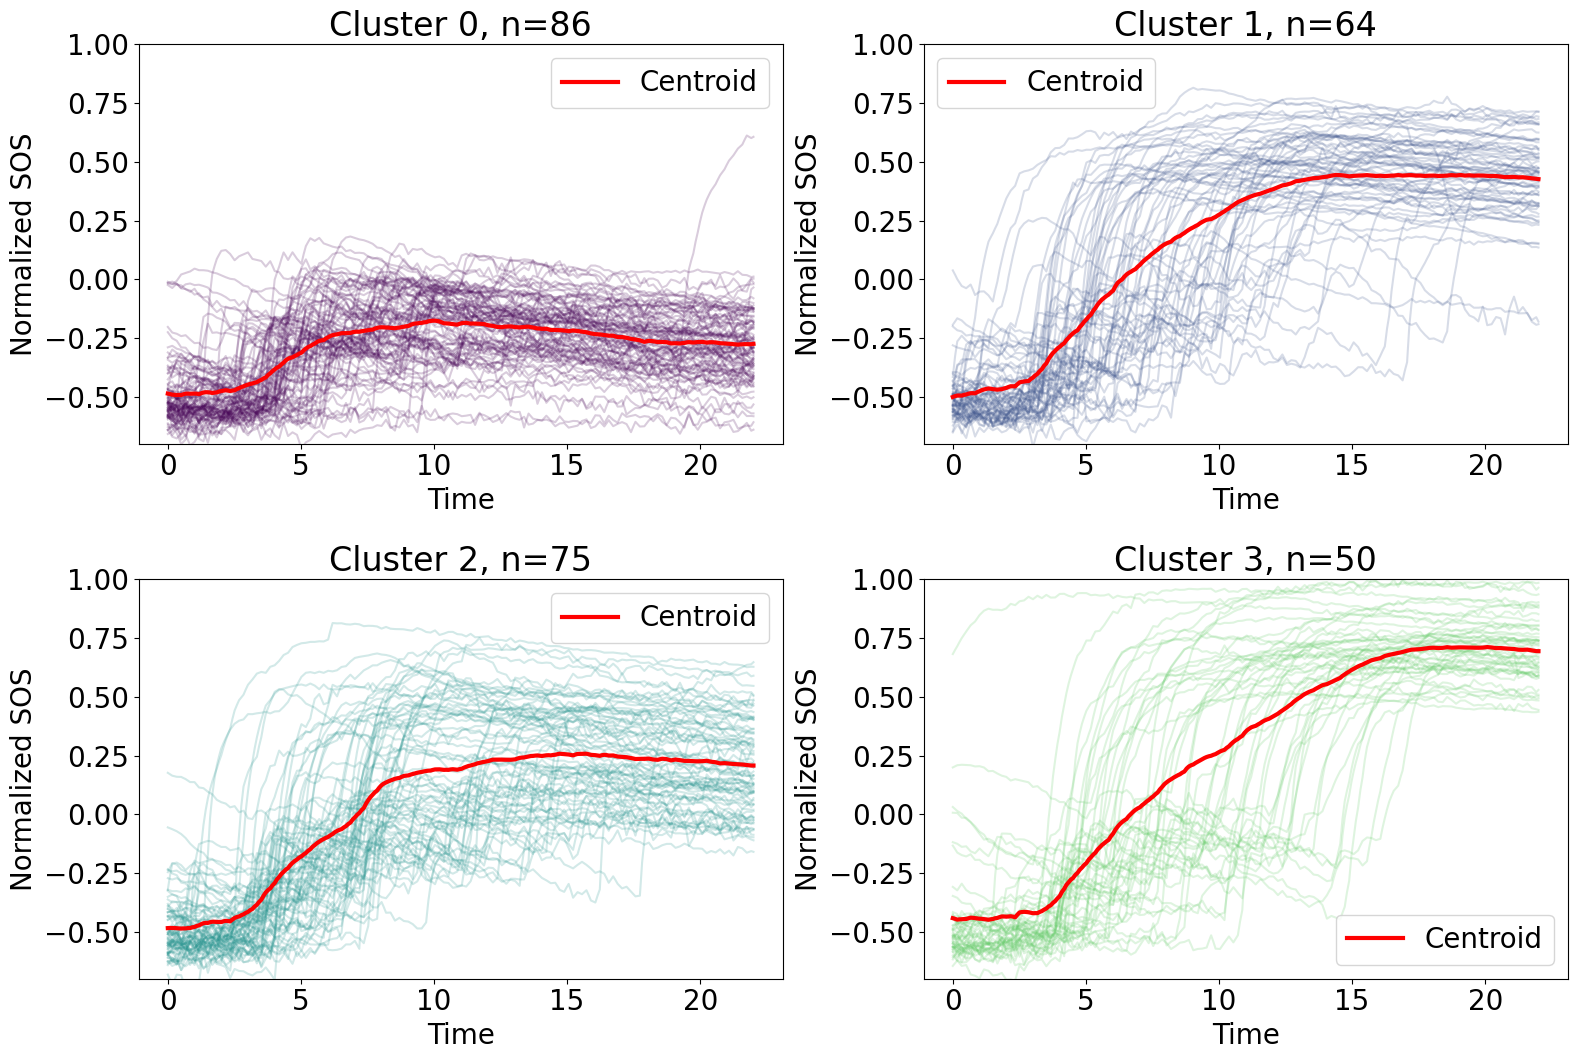

In [29]:
# clustering cell
n_cluster = 4

data_latent, data_y, data_series, data_rates = diers_dict['gly_cip'] 
# data_latent, data_y, data_series, data_rates = survivors_dict['glu_cip'] 
ylims = (-0.7,1)


kmeans_gluaa = KMeans(n_clusters=n_cluster, random_state=42, n_init=100)
clusters_gluaa = kmeans_gluaa.fit_predict(data_latent)

# # pca and tsne
# z_run_pca_gluaa = PCA(n_components=2).fit_transform(data_latent)
# z_run_tsne_gluaa = TSNE(perplexity=37, min_grad_norm=1E-12, n_iter=3000, learning_rate='auto', init='random').fit_transform(data_latent)

cmapvir = plt.get_cmap('viridis')
colors=[cmapvir(i) for i in np.linspace(0, 0.75, n_cluster)]
# hexcolors = [colors[i] for i in clusters_gluaa]

# fig, ax = plt.subplots(1, 2, figsize=(15, 7))
# ax[0].scatter(z_run_pca_gluaa[:, 0], z_run_pca_gluaa[:, 1], c=hexcolors, marker='x', alpha=0.8)
# ax[0].set_title(f'PCA Gluaa Cip Survivors k={n_cluster}')
# ax[0].set_xlabel('PC1')
# ax[0].set_ylabel('PC2')
# ax[1].scatter(z_run_tsne_gluaa[:, 0], z_run_tsne_gluaa[:, 1], c=hexcolors, marker='x', alpha=0.8)
# ax[1].set_title(f'tSNE Gluaa Cip Survivors k={n_cluster}')
# ax[1].set_xlabel('tSNE1')
# ax[1].set_ylabel('tSNE2')
# plt.tight_layout()
# plt.figure(figsize=(4,4))
# for i in range(4):
#     plt.scatter(-100,-100, color=colors[i], label=f'Cluster {i}', marker='x')
# plt.legend()

plt.rcParams.update({'font.size': 20})
times = np.linspace(0, 22,264)
widt = n_cluster//2 if n_cluster%2==0 else (n_cluster//2)+1
fig, ax = plt.subplots(2, widt, figsize=(8*widt, 11)) #fig, ax = plt.subplots(2, widt, figsize=(10*widt, 15))
axes = ax.flatten()
for c in range(n_cluster):
    for i,s in enumerate(data_series):
        if clusters_gluaa[i]==c:
            axes[c].plot(times, s[:,1].T, color=colors[c], alpha=0.2)
    axes[c].set_title(f'Cluster {c}, n={np.sum(clusters_gluaa==c)}')
    axes[c].set_xlabel('Time')
    axes[c].set_ylabel('Normalized SOS')
    axes[c].set_ylim(ylims)
plt.tight_layout()
# # add cluster centroids to the plots
for c in range(n_cluster):
    cluster_series = [data_series[i][:,1] for i in range(len(data_series)) if clusters_gluaa[i]==c]
    centroid = np.mean(cluster_series, axis=0)
    axes[c].plot(times, centroid, color='red', linewidth=3, label='Centroid')
    axes[c].legend()

y_serie = data_y
experiment_names = np.unique([f'{y[0]}_{y[1]}_{y[2]}' for y in y_serie], return_counts=True)[0]
per_exp_labels = [np.where(experiment_names == f'{y[0]}_{y[1]}_{y[2]}')[0][0] for y in y_serie]

ari = adjusted_rand_score(clusters_gluaa, per_exp_labels)
print('Adjusted Rand Index between KMeans clusters and experiment labels:\t',ari)

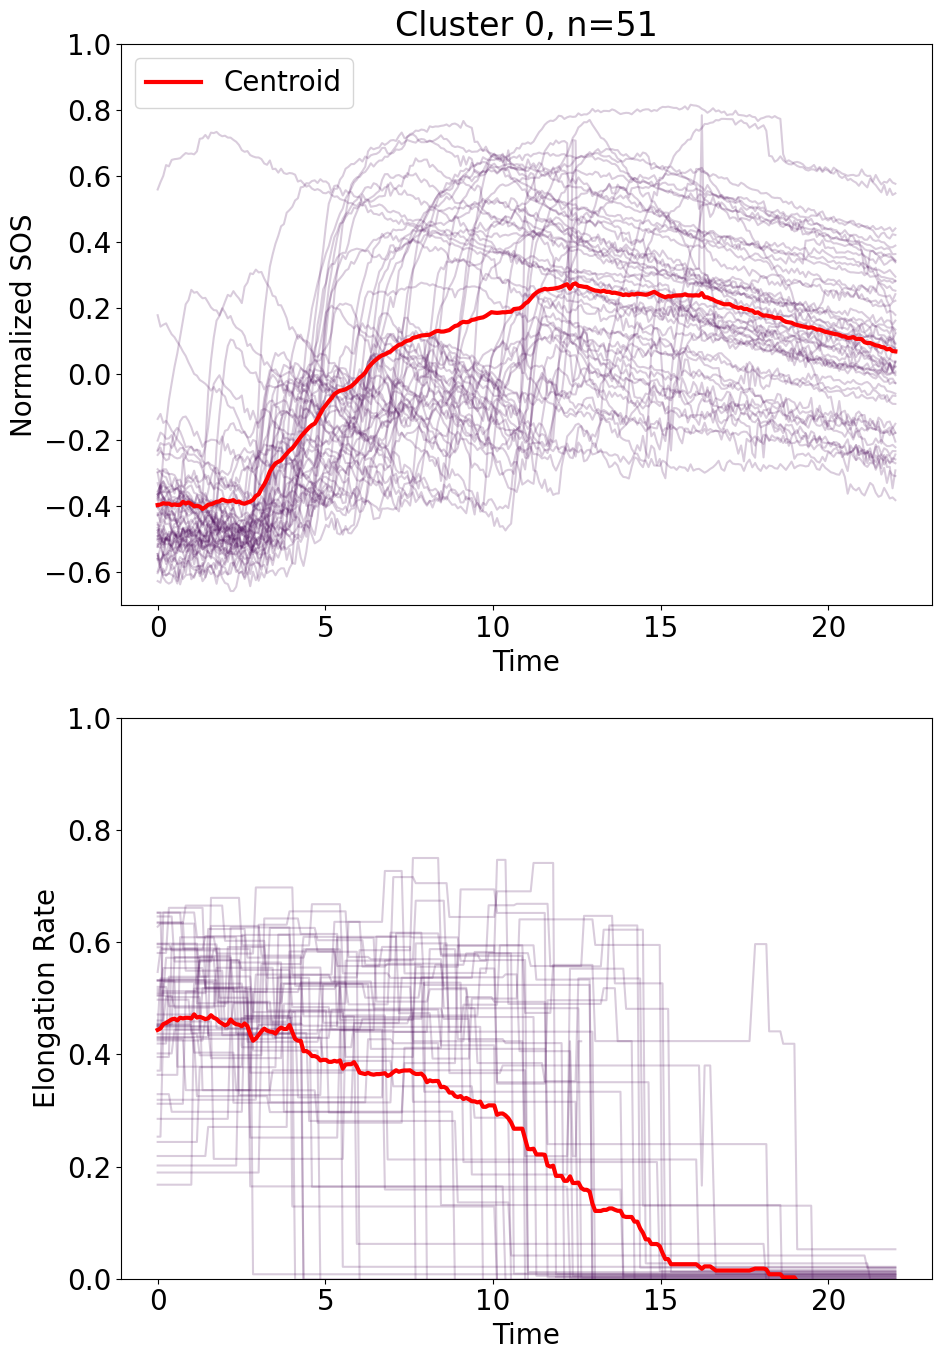

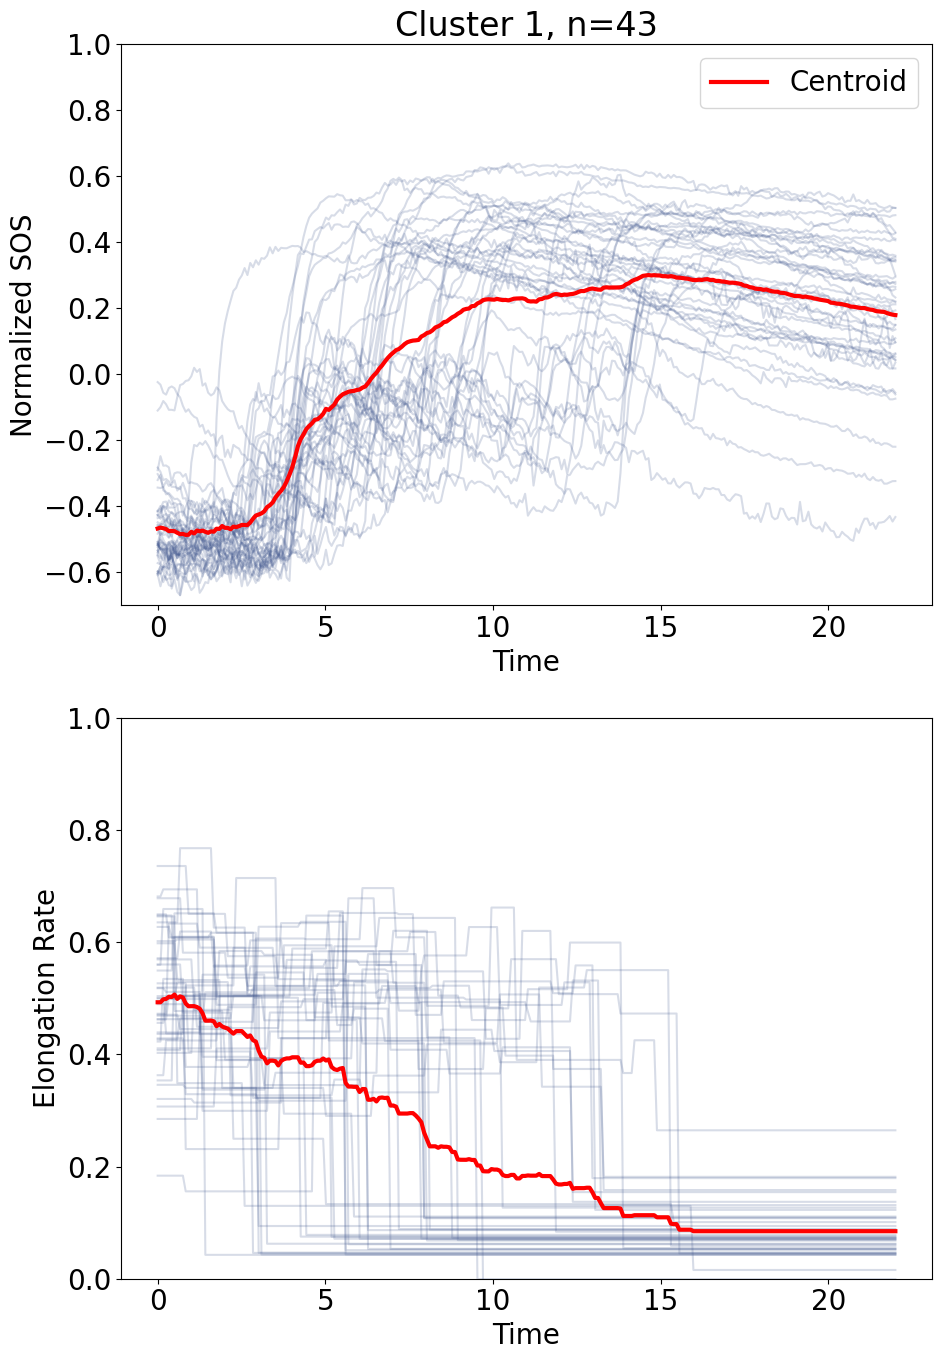

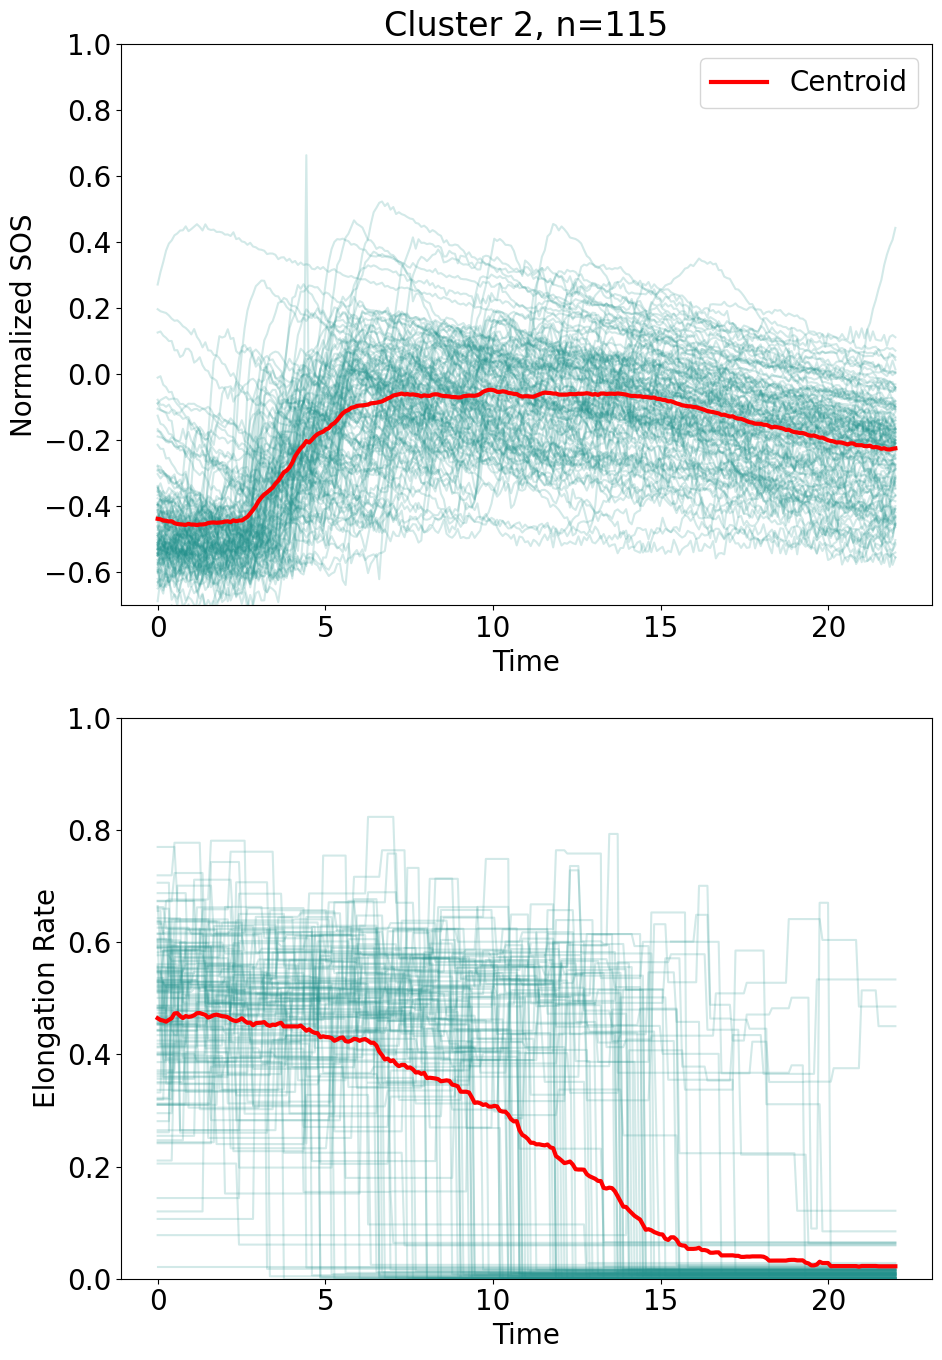

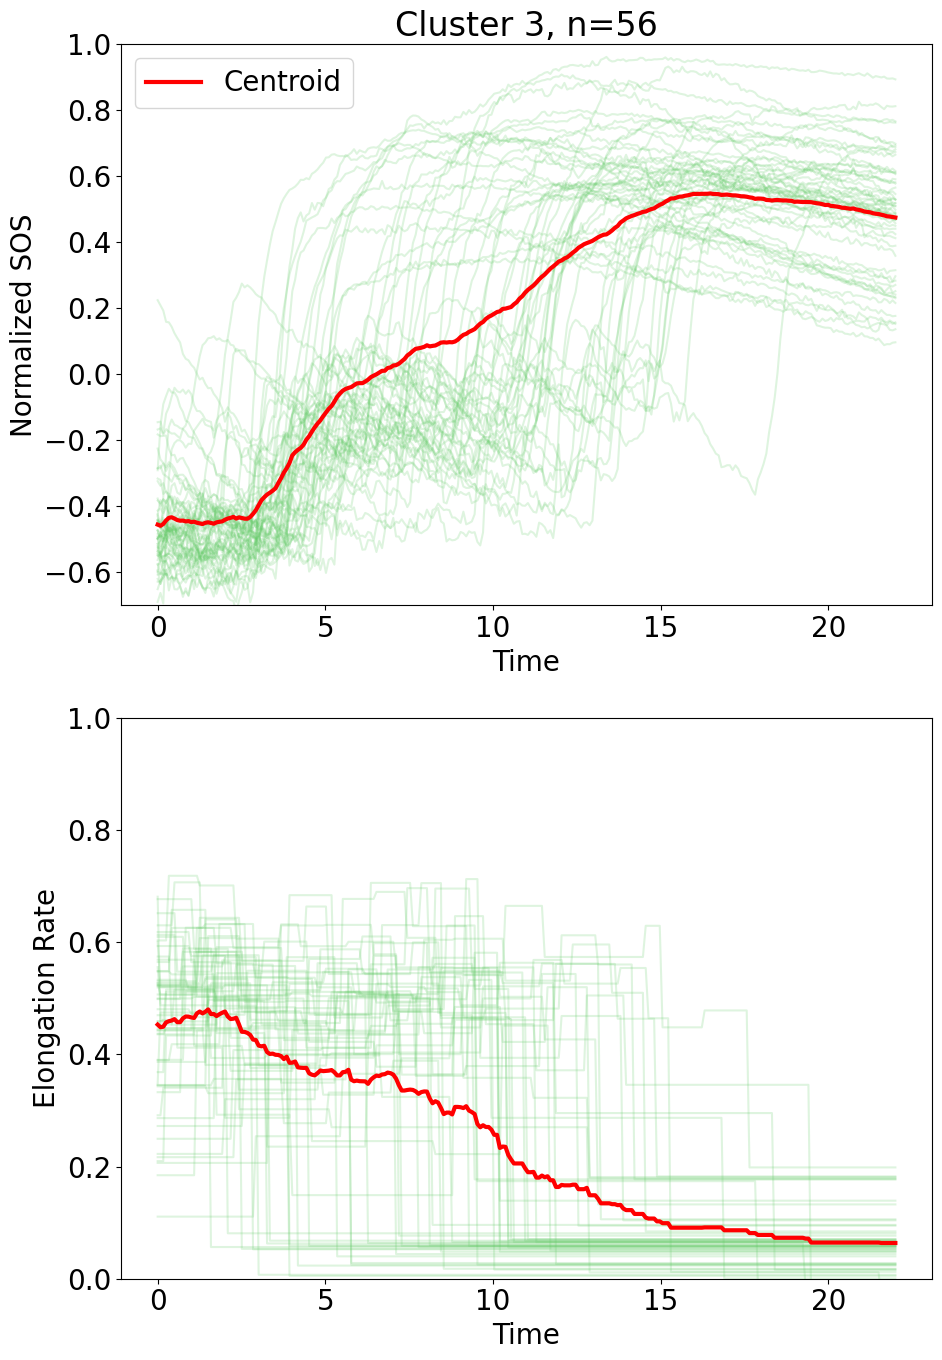

In [28]:
#plot each cluster separately as double plots sos and elongatiion below
for c in range(n_cluster):
    fig, ax = plt.subplots(2,1,figsize=(10, 14))
    for i,s in enumerate(data_series):
        if clusters_gluaa[i]==c:
            ax[0].plot(times, s[:,1].T, color=colors[c], alpha=0.2)
            ax[1].plot(times, data_rates[i], color=colors[c], alpha=0.2)
    ax[0].set_title(f'Cluster {c}, n={np.sum(clusters_gluaa==c)}')
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Normalized SOS')
    ax[0].set_ylim(ylims)
    # add cluster centroid
    cluster_series = [data_series[i][:,1] for i in range(len(data_series)) if clusters_gluaa[i]==c]
    sos_centroid = np.mean(cluster_series, axis=0)
    ax[0].plot(times, sos_centroid, color='red', linewidth=3, label='Centroid')
    ax[0].legend()

    # add elongation centroid
    cluster_rates = [data_rates[i] for i in range(len(data_rates)) if clusters_gluaa[i]==c]
    elongation_centroid = np.nanmean(cluster_rates, axis=0)
    ax[1].plot(times, elongation_centroid, color='red', linewidth=3, label='Centroid')
    ax[1].set_ylabel('Elongation Rate')
    ax[1].set_xlabel('Time')
    ax[1].set_ylim(0,1)
    plt.tight_layout()

In [ ]:
#plot each cluster separately as double plots sos and elongatiion below and mcherry below
for c in range(n_cluster):
    fig, ax = plt.subplots(2,1,figsize=(10, 14))
    for i,s in enumerate(data_series):
        if clusters_gluaa[i]==c:
            ax[0].plot(times, s[:,1].T, color=colors[c], alpha=0.2)
            ax[1].plot(times, data_rates[i], color=colors[c], alpha=0.2)
    ax[0].set_title(f'Cluster {c}, n={np.sum(clusters_gluaa==c)}')
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Normalized SOS')
    ax[0].set_ylim(ylims)
    # add cluster centroid
    cluster_series = [data_series[i][:,1] for i in range(len(data_series)) if clusters_gluaa[i]==c]
    sos_centroid = np.mean(cluster_series, axis=0)
    ax[0].plot(times, sos_centroid, color='red', linewidth=3, label='Centroid')
    ax[0].legend()

    # add elongation centroid
    cluster_rates = [data_rates[i] for i in range(len(data_rates)) if clusters_gluaa[i]==c]
    elongation_centroid = np.nanmean(cluster_rates, axis=0)
    ax[1].plot(times, elongation_centroid, color='red', linewidth=3, label='Centroid')
    ax[1].set_ylabel('Elongation Rate')
    ax[1].set_xlabel('Time')
    ax[1].set_ylim(0,2)
    plt.tight_layout()